# Лабораторная работа №2
# Студента группы Б05-321
# Листова Тихона
# 3.4 Метод наискорейшего спуска и метод минимальных невязок

## Техническое задание

Напишите программу для решения линейной системы с действительной матрицей  
$$Ax = b, \quad A = A^T > 0$$
методом минимальных невязок и методом наискорейшего спуска.

Требования к программе:  

1) Программа должна содержать функцию, которая принимает на вход матрицу A, правую часть b, максимальное число итераций, параметр tol для ограничения на норму невязки для критерия остановки итераций, флаг, который определяет с помощью какого из двух методов (метода наискорейшего спуска или метода минимальных невязок) нужно вычислять шаг $\tau$. Программа должна возвращать приближенное решение, вычисленное нужным методом, и массив со значениями невязки на каждой итерации.

2) Программа должна создавать симметричную положительно определенную матрицу размера n > 100, правую часть и вызывать реализованную функцию.

3) Программа должна выводить число итераций, точную ошибку (вычисленную по точному решению), а также график зависимости логарифма невязки от номера итерации.

4) Программа должна выводить время работы готовой функции (с помощью которой вычислялось точное решение), и время работы написанной функции. Для ускорения можно использовать декоратор @jit из пакета numba.

5) Автор программы должен уметь объяснить полученные результаты на основе изученной теории.

In [1]:
%pip install numba

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import jit

In [4]:
@jit(nopython=False)  # nopython=False, т.к. используем numpy функции, которые numba может не поддерживать в strict mode
def solver(A, b, max_iter, tol, is_steepest_descent):
    """
    Итерационный решатель для методов наискорейшего спуска (sd) и минимальных невязок (mr).
    @jit из numba для  ускорения вычислений в цикле.
    Функция принимает:
    - A: матрица системы (симметричная положительно определенная)
    - b: вектор правой части
    - max_iter: максимальное число итераций
    - tol: tolerance для нормы невязки (критерий остановки)
    - is_steepest_descent: Использовать ли наискорейший спуск или метод минимальных невязок
    Возвращает:
    - x_approx: приближенное решение
    - res_norms: список норм невязок на каждой итерации (включая начальную)
    """
    n = len(b)
    x = np.zeros(n)  # Начальное приближение x0 = 0
    r = b - np.dot(A, x)  # Начальная невязка r0 = b - A x0
    res_norms = [np.linalg.norm(r)]  # Список для хранения норм ||r_k||
    
    for k in range(max_iter):
        if res_norms[-1] < tol:
            break  # Остановка, если норма невязки меньше tol
        
        Ar = np.dot(A, r)  # Вычисляем A * r (общий для обоих методов)
        
        if is_steepest_descent:
            # Метод наискорейшего спуска:
            # alpha = (r^T r) / (r^T A r)
            # Это минимизирует квадратичную функцию f(x) = (1/2) x^T A x - b^T x
            # вдоль направления -gradient = r.
            alpha = np.dot(r, r) / np.dot(r, Ar)
        else:
            # Метод минимальных невязок:
            # alpha = (r^T A r) / (r^T A^2 r) = (r^T A r) / ( (A r)^T (A r) )
            # Это минимизирует норму невязки ||r_{k+1}|| = ||r_k - alpha A r_k||
            # в смысле L2-нормы.
            alpha = np.dot(r, Ar) / np.dot(Ar, Ar)
        
        x = x + alpha * r  # Обновление решения x_{k+1} = x_k + alpha r_k
        r = r - alpha * Ar  # Обновление невязки r_{k+1} = r_k - alpha A r_k
        res_norms.append(np.linalg.norm(r))  # Добавляем новую норму ||r_{k+1}||
    
    return x, res_norms

In [5]:
def generate_spd_matrix(n):
    """
    Функция для генерации симметричной положительно определенной матрицы размером n x n.
    Мы используем случайную матрицу U, вычисляем A = U^T * U + I, где I - единичная матрица,
    чтобы гарантировать положительную определенность (все собственные значения >0).
    """
    U = np.random.randn(n, n)
    A = np.dot(U.T, U) + np.eye(n)
    return A

In [6]:
def test_methods(A, b, x_true):
    # Вычисление точного решения с помощью np.linalg.solve и замер времени
    start_time = time.time()
    x_exact = np.linalg.solve(A, b)
    time_exact = time.time() - start_time
    print(f"Время точного решения (np.linalg.solve): {time_exact:.6f} секунд")
    for is_steepest_descent in [True, False]:
        if is_steepest_descent:
            method = "Метод наискорейшего спуска"
        else:
            method = "Метод минимальных невязок"
        print(method + ':')
        
        # Запуск итерационного решателя и замер времени
        start_time = time.time()
        x_approx, res_norms = solver(A, b, max_iter, tol, is_steepest_descent)
        time_iter = time.time() - start_time
        
        # Число итераций (len(res_norms) - 1, т.к. включает начальную невязку)
        num_iter = len(res_norms) - 1
        print(f"Число итераций: {num_iter}")
        
        # Точная ошибка ||x_approx - x_true||
        error = np.linalg.norm(x_approx - x_true)
        print(f"Точная ошибка ||x_approx - x_true||: {error:.6e}")
        
        # Время работы итерационной функции
        print(f"Время итерационного метода: {time_iter:.6f} секунд")
        
        # Построение графика log10(||r_k||) от номера итерации
        plt.figure(figsize = (13, 6))
        plt.plot(range(len(res_norms)), np.log10(res_norms), marker='o')
        plt.xlabel('Номер итерации')
        plt.ylabel('log10(||r_k||)')
        plt.title(f'Зависимость log невязки от итерации ({method})')
        plt.grid(True)
        plt.show()

Время точного решения (np.linalg.solve): 0.000578 секунд
Метод наискорейшего спуска:
Число итераций: 1000
Точная ошибка ||x_approx - x_true||: 1.433796e-01
Время итерационного метода: 3.126673 секунд


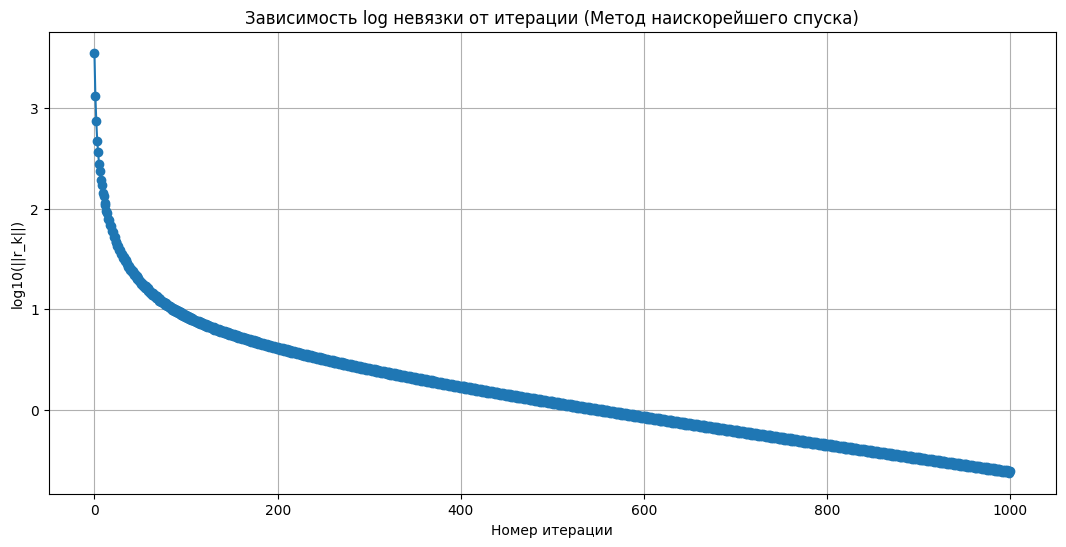

Метод минимальных невязок:
Число итераций: 1000
Точная ошибка ||x_approx - x_true||: 1.399981e-01
Время итерационного метода: 0.004411 секунд


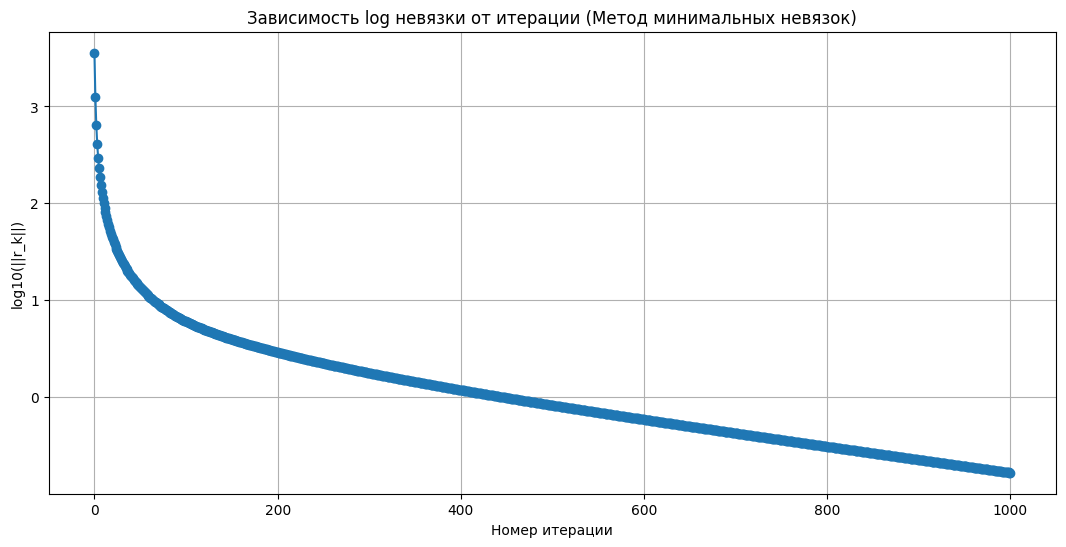

In [7]:
n = 200 # Размер матрицы n > 100
max_iter = 1000 # Максимальное число итераций
tol = 1e-6 # Tolerance для нормы невязки

# Генерация матрицы A и векторов
A = generate_spd_matrix(n)
x_true = np.random.randn(n) # Истинное решение (случайный вектор)
b = np.dot(A, x_true) # Правая часть b = A * x_true

test_methods(A, b, x_true)

Линейная скоость сходимости в обоих методах.

Тесты:  
\====================================================== 1 \======================================================

A = \begin{pmatrix}
60 & 30 & 20 \\
30 & 20 & 15 \\
20 & 15 & 12
\end{pmatrix}
b = \begin{pmatrix}
110 \\
65 \\
47
\end{pmatrix}

\====================================================== 2 \======================================================

A = \begin{pmatrix}
420 & 210 & 140 & 105 \\
210 & 140 & 105 & 84 \\
140 & 105 & 84 & 70 \\
105 & 84 & 70 & 60
\end{pmatrix}
b = \begin{pmatrix}
875 \\
539 \\
399 \\
319
\end{pmatrix}

\====================================================== 3 \======================================================

A= 
\begin{pmatrix}
\frac{1}{1} & \frac{1}{2} & \frac{1}{3} & \frac{1}{4} & \frac{1}{5} & \frac{1}{6} & \frac{1}{7} & \frac{1}{8} & \frac{1}{9} & \frac{1}{10} & \frac{1}{11} & \frac{1}{12} \\
\frac{1}{2} & \frac{1}{3} & \frac{1}{4} & \frac{1}{5} & \frac{1}{6} & \frac{1}{7} & \frac{1}{8} & \frac{1}{9} & \frac{1}{10} & \frac{1}{11} & \frac{1}{12} & \frac{1}{13} \\
\frac{1}{3} & \frac{1}{4} & \frac{1}{5} & \frac{1}{6} & \frac{1}{7} & \frac{1}{8} & \frac{1}{9} & \frac{1}{10} & \frac{1}{11} & \frac{1}{12} & \frac{1}{13} & \frac{1}{14} \\
\frac{1}{4} & \frac{1}{5} & \frac{1}{6} & \frac{1}{7} & \frac{1}{8} & \frac{1}{9} & \frac{1}{10} & \frac{1}{11} & \frac{1}{12} & \frac{1}{13} & \frac{1}{14} & \frac{1}{15} \\
\frac{1}{5} & \frac{1}{6} & \frac{1}{7} & \frac{1}{8} & \frac{1}{9} & \frac{1}{10} & \frac{1}{11} & \frac{1}{12} & \frac{1}{13} & \frac{1}{14} & \frac{1}{15} & \frac{1}{16} \\
\frac{1}{6} & \frac{1}{7} & \frac{1}{8} & \frac{1}{9} & \frac{1}{10} & \frac{1}{11} & \frac{1}{12} & \frac{1}{13} & \frac{1}{14} & \frac{1}{15} & \frac{1}{16} & \frac{1}{17} \\
\frac{1}{7} & \frac{1}{8} & \frac{1}{9} & \frac{1}{10} & \frac{1}{11} & \frac{1}{12} & \frac{1}{13} & \frac{1}{14} & \frac{1}{15} & \frac{1}{16} & \frac{1}{17} & \frac{1}{18} \\
\frac{1}{8} & \frac{1}{9} & \frac{1}{10} & \frac{1}{11} & \frac{1}{12} & \frac{1}{13} & \frac{1}{14} & \frac{1}{15} & \frac{1}{16} & \frac{1}{17} & \frac{1}{18} & \frac{1}{19} \\
\frac{1}{9} & \frac{1}{10} & \frac{1}{11} & \frac{1}{12} & \frac{1}{13} & \frac{1}{14} & \frac{1}{15} & \frac{1}{16} & \frac{1}{17} & \frac{1}{18} & \frac{1}{19} & \frac{1}{20} \\
\frac{1}{10} & \frac{1}{11} & \frac{1}{12} & \frac{1}{13} & \frac{1}{14} & \frac{1}{15} & \frac{1}{16} & \frac{1}{17} & \frac{1}{18} & \frac{1}{19} & \frac{1}{20} & \frac{1}{21} \\
\frac{1}{11} & \frac{1}{12} & \frac{1}{13} & \frac{1}{14} & \frac{1}{15} & \frac{1}{16} & \frac{1}{17} & \frac{1}{18} & \frac{1}{19} & \frac{1}{20} & \frac{1}{21} & \frac{1}{22} \\
\frac{1}{12} & \frac{1}{13} & \frac{1}{14} & \frac{1}{15} & \frac{1}{16} & \frac{1}{17} & \frac{1}{18} & \frac{1}{19} & \frac{1}{20} & \frac{1}{21} & \frac{1}{22} & \frac{1}{23}
\end{pmatrix}
b = \begin{pmatrix}
\sum_{j=0}^{11} \frac{1}{0+j+1} \\[6pt]
\sum_{j=0}^{11} \frac{1}{1+j+1} \\[6pt]
\vdots \\[6pt]
\sum_{j=0}^{11} \frac{1}{11+j+1}
\end{pmatrix}
\=
\begin{pmatrix}
\frac{86021}{27720} \\
\frac{785633}{360360} \\
\frac{631193}{360360} \\
\frac{535097}{360360} \\
\frac{935059}{720720} \\
\frac{2833255}{2450448} \\
\frac{853661}{816816} \\
\frac{14819303}{15519504} \\
\frac{68276701}{77597520} \\
\frac{190049623}{232792560} \\
\frac{177351847}{232792560} \\
\frac{3825136961}{5354228880}
\end{pmatrix}

\====================================================== 4 \======================================================

A = \begin{pmatrix}
76 & 5 & 1 & -2 & -3 & 9 & 1 & 1 & -6 & -2 & -7 & -8 & 2 & -4 & -8 & -9 \\
2 & 80 & 7 & 0 & 6 & 5 & 5 & 9 & 2 & -7 & -5 & 9 & -3 & -1 & -3 & 8 \\
-6 & 4 & 78 & -1 & -8 & 5 & -3 & 2 & -2 & 5 & -7 & 4 & 7 & -6 & 8 & -2 \\
-6 & -8 & -4 & 78 & -6 & 8 & 2 & -8 & 0 & -6 & 4 & 6 & 5 & -2 & 4 & -2 \\
6 & 3 & 8 & 5 & 77 & -1 & 5 & 3 & -9 & -3 & -1 & -9 & 2 & -2 & 1 & 9 \\
7 & -2 & -7 & -7 & -9 & 73 & 0 & -3 & -1 & -3 & -1 & -2 & 2 & -8 & -9 & 6 \\
-5 & -7 & 2 & -2 & -7 & -9 & 84 & -5 & 5 & 4 & -7 & -9 & -5 & 4 & -3 & -1 \\
5 & 5 & 0 & 3 & 9 & -3 & 7 & 67 & -5 & -3 & 3 & 5 & 1 & -6 & 3 & -3 \\
9 & -8 & 0 & 3 & -4 & 2 & 2 & 1 & 75 & -9 & -9 & 3 & -1 & -7 & -3 & -4 \\
-2 & -1 & -5 & -9 & 9 & 0 & 2 & 5 & -1 & 77 & 7 & 2 & -3 & -8 & -7 & 7 \\
-5 & 7 & 7 & 7 & -8 & -8 & -5 & -9 & -9 & 9 & 104 & 2 & -4 & -6 & 1 & 7 \\
-4 & -5 & -8 & -4 & 1 & 6 & 6 & -9 & -1 & -4 & 6 & 93 & -6 & 9 & -7 & 9 \\
-3 & -1 & -9 & -2 & -3 & 8 & -2 & -9 & 1 & 8 & 0 & -7 & 81 & 6 & 6 & 7 \\
-8 & -9 & 6 & 2 & -5 & -5 & -1 & -1 & -7 & 9 & 6 & 6 & -7 & 88 & 1 & 7 \\
-2 & -6 & -4 & -2 & -7 & 6 & -7 & 8 & 4 & 8 & -8 & -7 & 6 & -1 & 91 & -9 \\
-6 & -9 & 4 & 6 & -2 & -3 & -7 & 7 & -9 & 6 & 2 & 9 & 4 & -4 & -4 & 88
\end{pmatrix}

b = 
\begin{pmatrix}
46 \\
114 \\
78 \\
65 \\
94 \\
36 \\
39 \\
88 \\
50 \\
73 \\
90 \\
82 \\
81 \\
82 \\
70 \\
82
\end{pmatrix}

In [9]:
A12 = np.array([[1.0 / (i + j + 1) for j in range(12)] for i in range(12)])
test_cases = [
    (np.array([
    [60., 30., 20.],
    [30., 20., 15.],
    [20., 15., 12.]
    ]), 
     np.array([110., 65., 47.]),
     np.ones(3)),
    (np.array([
    [420., 210., 140., 105.],
    [210., 140., 105., 84.],
    [140., 105., 84., 70.],
    [105., 84., 70., 60.]
    ]),
     np.array([875., 539., 399., 319.]),
     np.ones(4)),
    (A12, 
     np.sum(A12, axis=1),
     np.ones(12)),
    (np.array([
    [76., 5., 1., -2., -3., 9., 1., 1., -6., -2., -7., -8., 2., -4., -8., -9.],
    [2., 80., 7., 0., 6., 5., 5., 9., 2., -7., -5., 9., -3., -1., -3., 8.],
    [-6., 4., 78., -1., -8., 5., -3., 2., -2., 5., -7., 4., 7., -6., 8., -2.],
    [-6., -8., -4., 78., -6., 8., 2., -8., 0., -6., 4., 6., 5., -2., 4., -2.],
    [6., 3., 8., 5., 77., -1., 5., 3., -9., -3., -1., -9., 2., -2., 1., 9.],
    [7., -2., -7., -7., -9., 73., 0., -3., -1., -3., -1., -2., 2., -8., -9., 6.],
    [-5., -7., 2., -2., -7., -9., 84., -5., 5., 4., -7., -9., -5., 4., -3., -1.],
    [5., 5., 0., 3., 9., -3., 7., 67., -5., -3., 3., 5., 1., -6., 3., -3.],
    [9., -8., 0., 3., -4., 2., 2., 1., 75., -9., -9., 3., -1., -7., -3., -4.],
    [-2., -1., -5., -9., 9., 0., 2., 5., -1., 77., 7., 2., -3., -8., -7., 7.],
    [-5., 7., 7., 7., -8., -8., -5., -9., -9., 9., 104., 2., -4., -6., 1., 7.],
    [-4., -5., -8., -4., 1., 6., 6., -9., -1., -4., 6., 93., -6., 9., -7., 9.],
    [-3., -1., -9., -2., -3., 8., -2., -9., 1., 8., 0., -7., 81., 6., 6., 7.],
    [-8., -9., 6., 2., -5., -5., -1., -1., -7., 9., 6., 6., -7., 88., 1., 7.],
    [-2., -6., -4., -2., -7., 6., -7., 8., 4., 8., -8., -7., 6., -1., 91., -9.],
    [-6., -9., 4., 6., -2., -3., -7., 7., -9., 6., 2., 9., 4., -4., -4., 88.],
    ]),
     np.array([46., 114., 78., 65., 94., 36., 39., 88., 50., 73., 90., 82., 81., 82., 70., 82.]),
     np.ones(16)) 
]


--- Тест 1 ---
Матрица A:
 [[60. 30. 20.]
 [30. 20. 15.]
 [20. 15. 12.]]
Правая часть b: [110.  65.  47.]
Точное решение: x_true: [1. 1. 1.]
Время точного решения (np.linalg.solve): 0.000050 секунд
Метод наискорейшего спуска:
Число итераций: 1000
Точная ошибка ||x_approx - x_true||: 1.832370e-03
Время итерационного метода: 0.000751 секунд


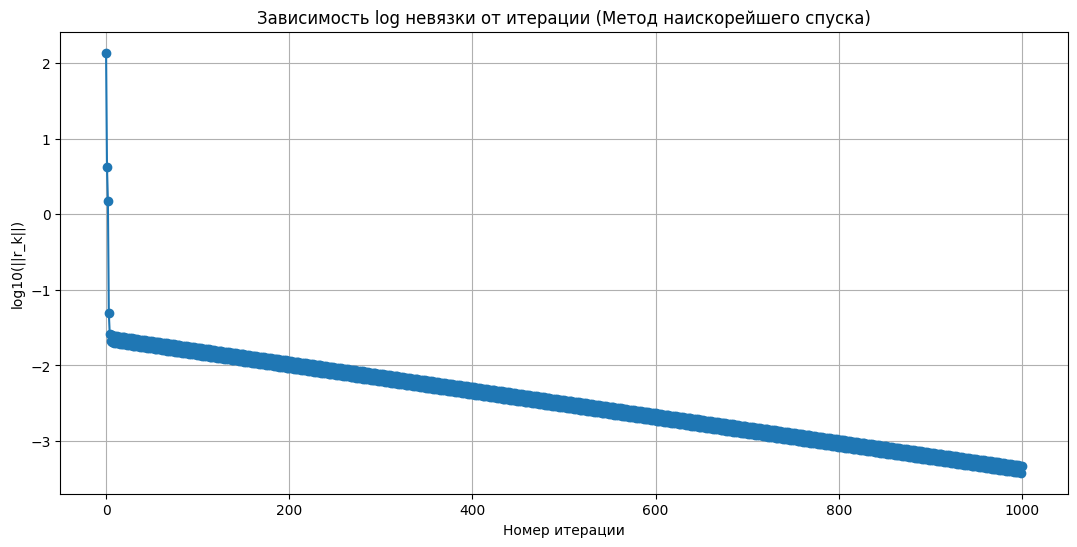

Метод минимальных невязок:
Число итераций: 865
Точная ошибка ||x_approx - x_true||: 6.138052e-06
Время итерационного метода: 0.000701 секунд


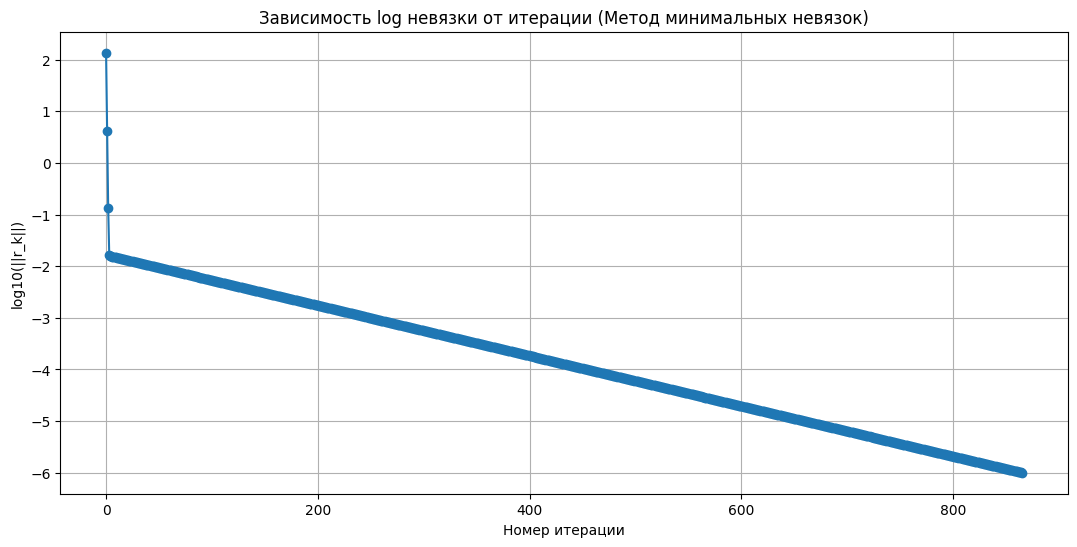


--- Тест 2 ---
Матрица A:
 [[420. 210. 140. 105.]
 [210. 140. 105.  84.]
 [140. 105.  84.  70.]
 [105.  84.  70.  60.]]
Правая часть b: [875. 539. 399. 319.]
Точное решение: x_true: [1. 1. 1. 1.]
Время точного решения (np.linalg.solve): 0.000034 секунд
Метод наискорейшего спуска:
Число итераций: 1000
Точная ошибка ||x_approx - x_true||: 1.988047e-02
Время итерационного метода: 0.000659 секунд


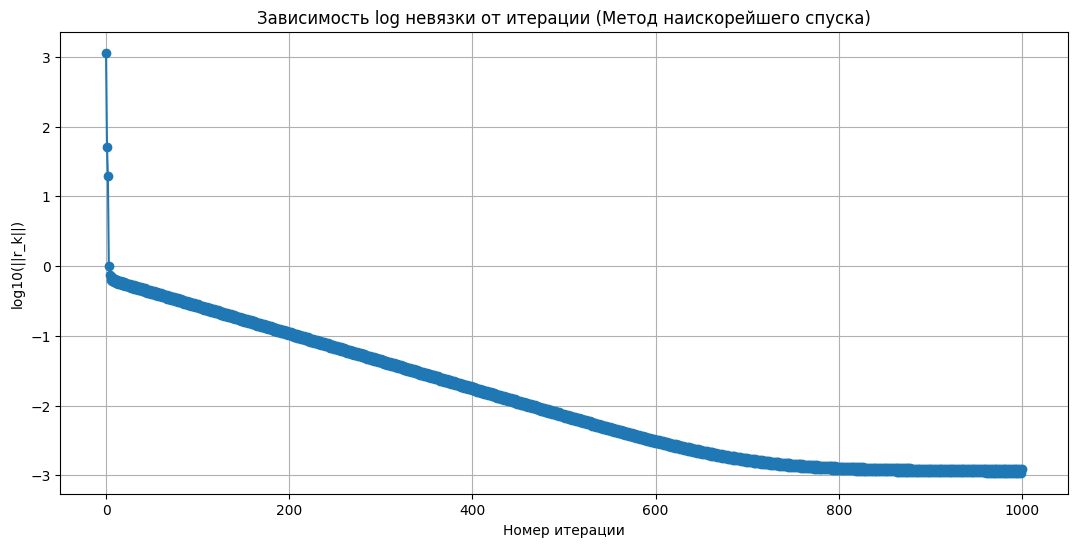

Метод минимальных невязок:
Число итераций: 1000
Точная ошибка ||x_approx - x_true||: 1.771972e-02
Время итерационного метода: 0.000656 секунд


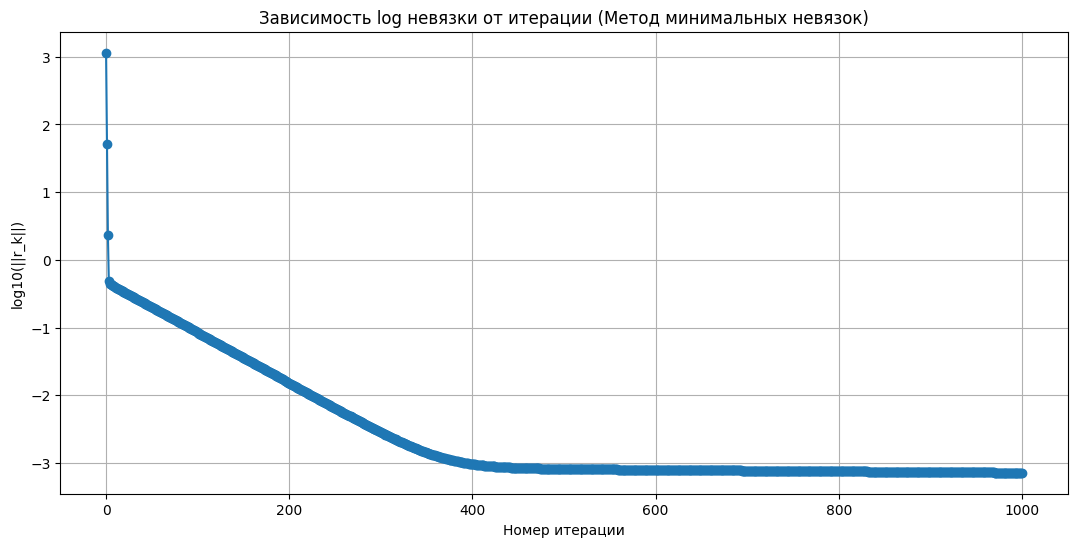


--- Тест 3 ---
Матрица A:
 [[1.         0.5        0.33333333 0.25       0.2        0.16666667
  0.14285714 0.125      0.11111111 0.1        0.09090909 0.08333333]
 [0.5        0.33333333 0.25       0.2        0.16666667 0.14285714
  0.125      0.11111111 0.1        0.09090909 0.08333333 0.07692308]
 [0.33333333 0.25       0.2        0.16666667 0.14285714 0.125
  0.11111111 0.1        0.09090909 0.08333333 0.07692308 0.07142857]
 [0.25       0.2        0.16666667 0.14285714 0.125      0.11111111
  0.1        0.09090909 0.08333333 0.07692308 0.07142857 0.06666667]
 [0.2        0.16666667 0.14285714 0.125      0.11111111 0.1
  0.09090909 0.08333333 0.07692308 0.07142857 0.06666667 0.0625    ]
 [0.16666667 0.14285714 0.125      0.11111111 0.1        0.09090909
  0.08333333 0.07692308 0.07142857 0.06666667 0.0625     0.05882353]
 [0.14285714 0.125      0.11111111 0.1        0.09090909 0.08333333
  0.07692308 0.07142857 0.06666667 0.0625     0.05882353 0.05555556]
 [0.125      0.11111111 0

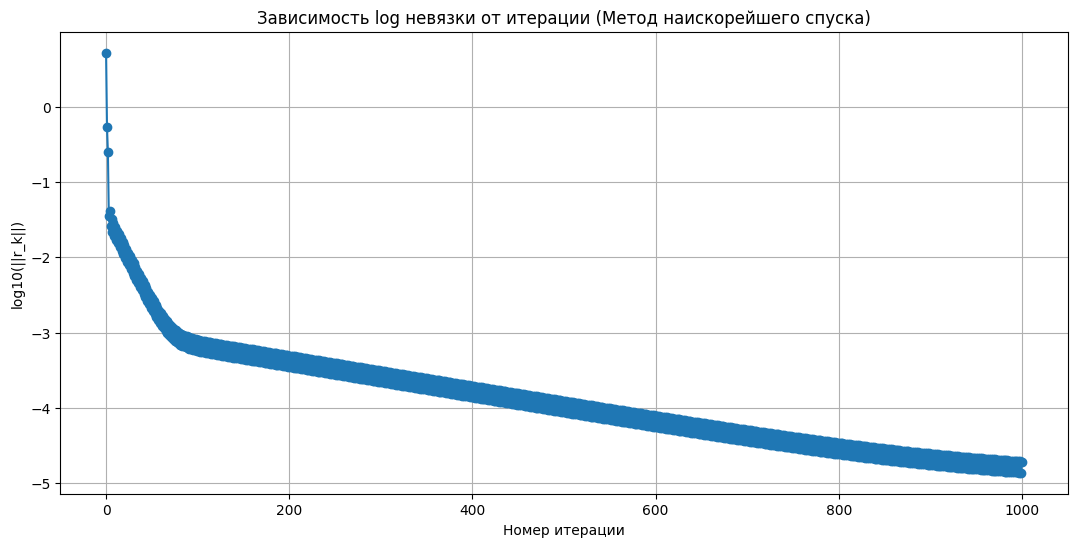

Метод минимальных невязок:
Число итераций: 1000
Точная ошибка ||x_approx - x_true||: 4.101301e-02
Время итерационного метода: 0.000726 секунд


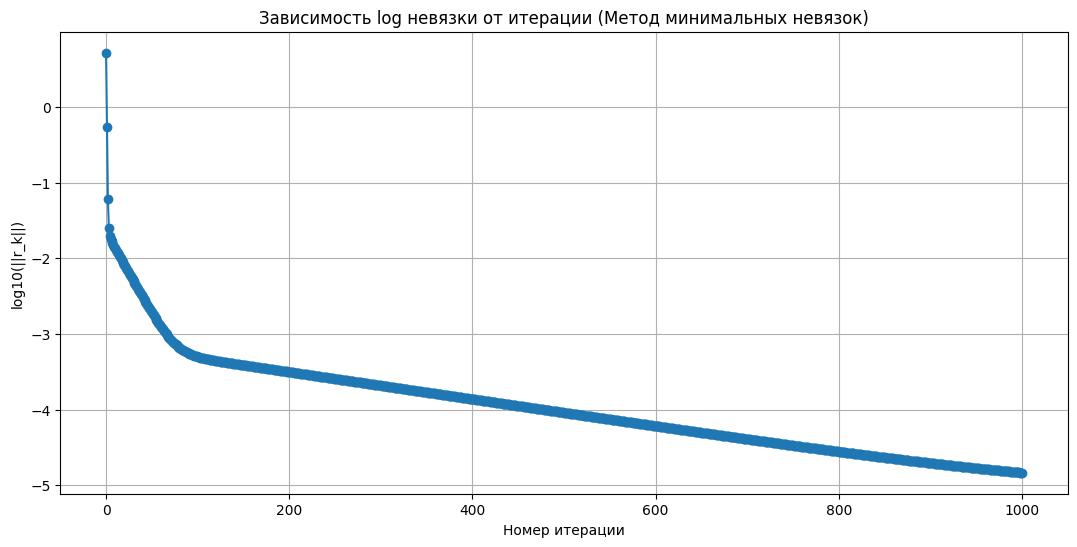


--- Тест 4 ---
Матрица A:
 [[ 76.   5.   1.  -2.  -3.   9.   1.   1.  -6.  -2.  -7.  -8.   2.  -4.
   -8.  -9.]
 [  2.  80.   7.   0.   6.   5.   5.   9.   2.  -7.  -5.   9.  -3.  -1.
   -3.   8.]
 [ -6.   4.  78.  -1.  -8.   5.  -3.   2.  -2.   5.  -7.   4.   7.  -6.
    8.  -2.]
 [ -6.  -8.  -4.  78.  -6.   8.   2.  -8.   0.  -6.   4.   6.   5.  -2.
    4.  -2.]
 [  6.   3.   8.   5.  77.  -1.   5.   3.  -9.  -3.  -1.  -9.   2.  -2.
    1.   9.]
 [  7.  -2.  -7.  -7.  -9.  73.   0.  -3.  -1.  -3.  -1.  -2.   2.  -8.
   -9.   6.]
 [ -5.  -7.   2.  -2.  -7.  -9.  84.  -5.   5.   4.  -7.  -9.  -5.   4.
   -3.  -1.]
 [  5.   5.   0.   3.   9.  -3.   7.  67.  -5.  -3.   3.   5.   1.  -6.
    3.  -3.]
 [  9.  -8.   0.   3.  -4.   2.   2.   1.  75.  -9.  -9.   3.  -1.  -7.
   -3.  -4.]
 [ -2.  -1.  -5.  -9.   9.   0.   2.   5.  -1.  77.   7.   2.  -3.  -8.
   -7.   7.]
 [ -5.   7.   7.   7.  -8.  -8.  -5.  -9.  -9.   9. 104.   2.  -4.  -6.
    1.   7.]
 [ -4.  -5.  -8.  -4.   1.   6.   6. 

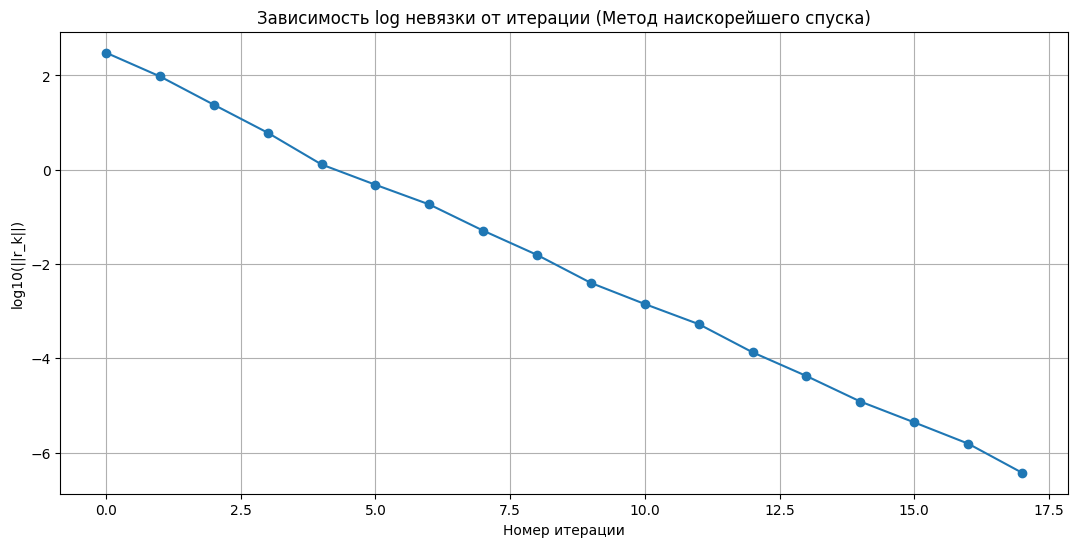

Метод минимальных невязок:
Число итераций: 17
Точная ошибка ||x_approx - x_true||: 4.392452e-09
Время итерационного метода: 0.000051 секунд


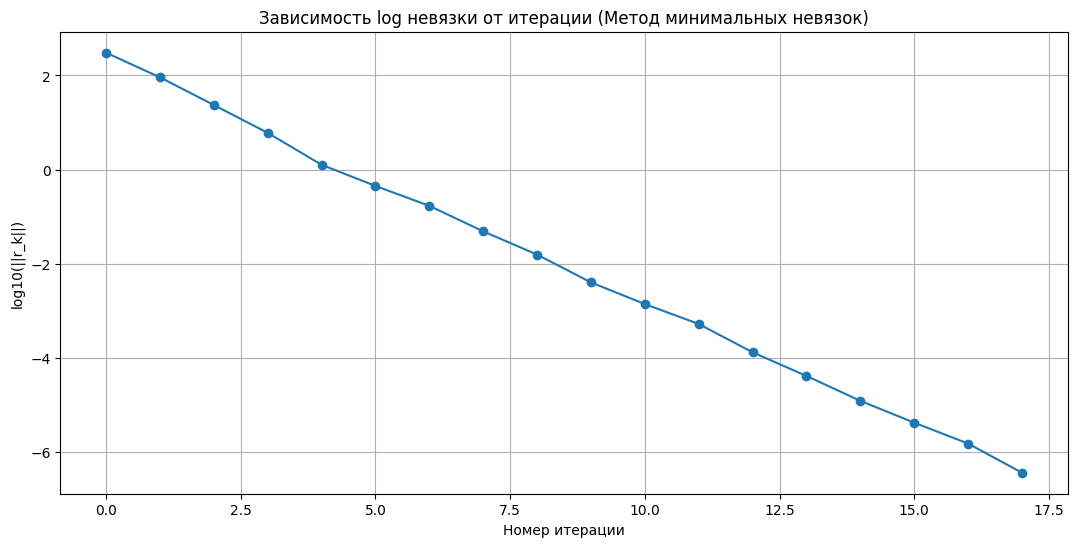

In [11]:
for i, (A, b, x_true) in enumerate(test_cases):
    print(f"\n--- Тест {i+1} ---")
    print("Матрица A:\n", A)
    print("Правая часть b:", b)
    print("Точное решение: x_true:", x_true)

    test_methods(A, b, x_true)
    